This notebook is a template for cumulative sum calculations on experimental data in form of a histogram published by authors. You can input your binned date to this code and an estimation of N, slope and Mass will be made with their corresponding estimated errors.

### Necessary functions

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import linregress
from sklearn.metrics import r2_score
from tqdm import tqdm
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm

In [3]:
# Binning and cumulative sum
def cumulative_sum(lower_limits, counts):
    
    """ 
    Returns cumulative sum counts.
    Plots cumulative sum with dependance on lower bin limit in a log-log scale. 
    """

    cumulative_counts = counts[::-1].cumsum()[::-1]
    
    plt.figure(figsize=(4,4))
    plt.xscale('log')
    plt.yscale('log')
    plt.plot(lower_limits, cumulative_counts, marker='o')
    plt.xlabel('Log lower bin limit')
    plt.ylabel("log cumulative counts")
    plt.title('Log log scale distribution')
    
    return cumulative_counts
    

In [4]:
def finding_N(first_bin,last_bin, cumulative_counts, lower_bin_limits, xmin, xmax):
   
    """
    Erases the tail or/and head of the distribution.
    Returns cumulative sum slope,intercept and N.
    """
    # Chosen bins verification
    if len(cumulative_counts) < last_bin:
        print('Problem: You have chosen a wrong number of bins! There is less bins than you wish to use.')
        return
        
    # Adjusting the bins 
    first_bin=first_bin-1
    counts_kept = cumulative_counts[first_bin:last_bin]
    bins_kept = lower_bin_limits[first_bin:last_bin]

    # Chosen bins verification
    if len(counts_kept) < 3:
        print('Problem: There is not enough bins to do linear regression! There must be at least 3 bins.')
        return
    if counts_kept[len(counts_kept)-1] < 1:
        print('Problem: There is not enough particles in the last bin! The last bin must contain at least 1 particle to be taken in account.')
        return
        
    # Finding slope & intercept of cumulative distribution
    log_bins_kept = np.log10(bins_kept)
    log_counts_kept = np.log10(counts_kept)
    log_bins = np.log10(lower_bin_limits)
    log_counts = np.log10(cumulative_counts)
    slope_cumsum, intercept_cumsum, *_ = linregress(log_bins_kept, log_counts_kept) ### *_ ignores following variables

    # Ploting linear regression
    plt.figure(figsize=(4,4))
    plt.scatter(log_bins,log_counts,marker='o',label='Full distribution')
    plt.scatter(log_bins_kept,log_counts_kept,marker='o',label='Used for linear regression')
    plt.plot(log_bins,slope_cumsum*log_bins+intercept_cumsum, label='Linear regression',color='green')
    plt.xlabel('Log lower bin limit')
    plt.ylabel("Log cumulative counts")
    plt.title('Log log scale size distribution')
    plt.legend()
    plt.show()

    # Computing N using cumulative sum slope & intercept
    N_1 = slope_cumsum*np.log10(xmin)+intercept_cumsum
    N_5000=slope_cumsum*np.log10(xmax)+intercept_cumsum
    N = 10**N_1-10**N_5000

    # Particle size distribution parameters
    slope = slope_cumsum-1
    intercept = (N*(slope+1))/(xmax**(slope+1)-xmin**(slope+1))

    return int(N), slope, intercept
    

In [5]:
def particle_size_distribution(LOD_min, LOD_max, total_concentration, slope_cumsum):
    slope = slope_cumsum-1
    intercept = (total_concentration*(slope+1))/(LOD_max**(slope+1)-LOD_min**(slope+1))

    New_N=(intercept/(slope+1))/(5000**(slope+1)-1**(slope+1))
    
    return slope, intercept, New_N
    

In [6]:
def error_evaluation(slope, LODs_low, LOD_high, ns, xmin, xmax):
    """
    Defines sumulated ssampling within the real sampling conditions (LOD lower, LOD upper, n)
    
    """

    results = []
    
    # Simulated samplings
    for slope_th in tqdm(slopes, desc="Slope loop"):
        for LOD_min in LODs_low:
            # Bin generation with step *= 1.5 pattern
            if LOD_min <= 50 : step = 2
            elif 100 <= LOD_min <= 200 : step = 5
            elif LOD_min >= 200 and slope_th >= -2. :step = 15
            else : step =10
            
            edges = [LOD_min]
            while True:
                next_edge = edges[-1] + step
                if next_edge >= LOD_high:
                    break
                edges.append(next_edge)
                step *= 1.5
            bin_edges = np.array(edges)
            
        
            for n_sampled in ns:
                all_samplings = []

                for distribution in range(200):
                    random_sequence = np.random.uniform(0, 1, n_sampled)
                    size_distribution = simulated_sampling(
                    LOD_min_ss=LOD_min, LOD_max_ss=LOD_high,b_ss=slope_th, samples_ss=random_sequence)
                    all_samplings.append(size_distribution)
                    
                # Cumulative counts
                cumulative_counts = cumulative_sum_(bin_edges, all_samplings)
                
                to_modify, bin_threshold = determine_bin_threshold(n_sampled, LOD_min, slope_th)

                # Error on slope and N evaluation
                result = evaluation_of_binsize(bins_to_modify=to_modify,
                    minimal_bins_used=bin_threshold,
                    cumulative_counts_all_samplings_eb=cumulative_counts,
                    lower_bin_limits_eb=bin_edges,slope_th=slope_th,plot_debug=True)

                
                if result is not None:
                    results.append([slope_th, LOD_min, n_sampled, result['mean_slope_err'],result['N_error']])
                else: print('Problem in evaluation of binsize')
                    
    results_df = pd.DataFrame(results, columns=['slope', 'LOD lower', 'n', 'slope_error', 'N_error'])
    results_df['slope']=results_df['slope'].apply(lambda x: round(x, 4))
    return results_df

def simulated_sampling(LOD_min_ss, LOD_max_ss, b_ss, samples_ss):
    
    """
    Sample particles from power-law distribution within LOD bounds.
    """
    part_sampled = sample_power_law(LOD_min_ss, LOD_max_ss, b_ss, samples_ss) # if we dont have N
    if len(part_sampled)==0: print('Problem: There is not enough particles in the LOD range')
    return np.sort(part_sampled) 

def sample_power_law(xmin_spl, xmax_spl, b_spl, distribution_spl):
    
    """
    Samples particle sizes following a power-law distribution.
    """
    exponent = b_spl + 1
    norm = xmax_spl**exponent - xmin_spl**exponent
    MP_size = (distribution_spl * norm + xmin_spl**exponent) ** (1 / exponent)
    return MP_size
    

def cumulative_sum_(bins_cs, samplings_cs):
    
    """
    Function used for error evaluation exculsively.
    Return cumulative sum for each sampling.
    """
    
    lower_bin_limits = bins_cs
    cumulative_counts_all_samplings = []
    for i in range(len(samplings_cs)):
        cumulative_counts = np.array([(samplings_cs[i] >= limit).sum() for limit in lower_bin_limits])
        cumulative_counts_all_samplings.append(cumulative_counts)
    return cumulative_counts_all_samplings

def evaluation_of_binsize(bins_to_modify,minimal_bins_used, cumulative_counts_all_samplings_eb, lower_bin_limits_eb, slope_th, plot_debug=False):
    
    """
    Function used for error evaluation exculsively.
    Plots diagnostics of threshold usage.
    Evaluates slope and N error.
    """
    slopes_all_samplings = []
    intercepts_all_samplings = []
    slope_err_all_samplings = []
    r2_all_samplings= []
    N_all_samplings=[]
    
    for i in range(len(cumulative_counts_all_samplings_eb)):
        counts = cumulative_counts_all_samplings_eb[i]
        if len(counts) < minimal_bins_used:
            print('Problem: There is not enough bins. Change threshold numero',bins_to_modify)
            continue
        counts_kept = counts[:minimal_bins_used]
        bins_kept = lower_bin_limits_eb[:minimal_bins_used]
        if counts_kept[-1] < 1:
            print('Problem: There is not enough particles in the last bin. Change threshold',bins_to_modify)
            continue
        log_bins = np.log10(bins_kept)
        log_counts = np.log10(counts_kept)
        slope, intercept, *_ = linregress(log_bins, log_counts) ### *_ ignores following variables
        slope_noncumul = slope - 1
        slope_err = slope_noncumul - slope_th
        r2 = r2_score(log_counts, slope * log_bins + intercept)
        slopes_all_samplings.append(slope)
        intercepts_all_samplings.append(intercept)
        slope_err_all_samplings.append(slope_err)
        r2_all_samplings.append(r2)
        
        N1=slope*np.log10(1)+intercept
        N5000=slope*np.log10(100)+intercept
        N=10**N1-10**N5000
        N_all_samplings.append(N)
        
        if plot_debug and i == 0:
            print('slope:',slope_th,'LOD:',bins_kept[0], 'n:', counts_kept[0])
            plot_threshold_diagnostic(lower_bin_limits_eb, counts, minimal_bins_used, slope, intercept)

    if not slopes_all_samplings:
        return None
        
    mean_N=np.mean(N_all_samplings)
    error_on_N=np.absolute(mean_N-N_all_samplings)
    N_error=np.max(error_on_N)/mean_N
    
    slope_err_all_samplings = np.abs(slope_err_all_samplings)
    return {
        'mean_slope_err': np.mean(slope_err_all_samplings),
        'r2': np.mean(r2_all_samplings),
        'N_error': N_error
    }
    
def plot_threshold_diagnostic(lower_bins, cumulative_counts, minimal_bins_used, slope, intercept):
    
    """
    Function used for error evaluation exculsively.
    Plot diagnostic showing bins used vs. removed.
    """
    plt.figure(figsize=(6, 4))
    plt.loglog(lower_bins, cumulative_counts, 'ko-', label='All bins')
    plt.loglog(lower_bins[:minimal_bins_used], cumulative_counts[:minimal_bins_used], 'go-', label='Kept bins')
    plt.loglog(lower_bins[minimal_bins_used:], cumulative_counts[minimal_bins_used:], 'ro-', label='Dropped bins')
    x_fit = lower_bins
    y_fit = 10 ** (slope * np.log10(x_fit) + intercept)
    plt.loglog(x_fit, y_fit, 'b--', label='Linear fit')
    plt.xlabel('Lower bin limit')
    plt.ylabel('Cumulative count')
    plt.title('Threshold diagnostic')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
def determine_bin_threshold(n_sample, LOD_min, slope_th):
    
    """
    Function used for error evaluation exculsively.
    Customed rules to define threshold based on observed cases.
    Threshold can be modified if not coherent with input parameters.
    """
    
    # Custom cases based on updated user rules

    if slope_th < -2.0 and LOD_min > 20.0 and n_sample < 100:
        threshold = 5
        return 0, threshold
    if slope_th == -3.4 and LOD_min == 5 and n_sample > 1000:
        threshold = 7
        return 1, threshold
        
    if LOD_min > 50 and 250 < n_sample < 1000:
        threshold = 8
        return 2, threshold
        
    if slope_th > -2 and LOD_min > 50:
        threshold = 9
        return 3, threshold
        
    if slope_th > -1.4:
        threshold = 5
        return 4, threshold

    # Base cases
    if n_sample <= 50:
        if LOD_min > 130:
            threshold = 9
            return 5, threshold
            
        elif slope_th <= -2:
            threshold = 5
            return 6, threshold
        else:
            threshold = 5
            return 7, threshold
            
    elif n_sample >= 1000:
        if LOD_min > 130:
            threshold = 9
            return 8, threshold
            
        else:
            threshold = 8
            return 9, threshold
            
    else:
        threshold = 5
        return 10, threshold
            

In [7]:
def error_plot(n_fixed, LOD_fixed, results_df):
    
    # Filter the data 
    df_slice = results_df[results_df['n'] == n_fixed]
    df_slice = df_slice.sort_values(by=['n', 'LOD lower'])

    df_slice2 = df_slice[df_slice['LOD lower'] == LOD_fixed]

    pivot_N = df_slice2.pivot(index='LOD lower', columns='slope', values='N_error')
    pivot_slope = df_slice2.pivot(index='LOD lower', columns='slope', values='slope_error')

    # N error
    plt.figure(figsize=(8, 2))
    sns.heatmap(
        pivot_N,
        cmap='Reds',
        cbar_kws={'label': 'Multiplicative N error'},
        linewidths=0.3,
        linecolor='black',

        annot=True,
        fmt=".2f"
    )
    plt.title(f" n fixed at {n_fixed} and LOD fixed at {LOD_fixed}")
    plt.xlabel("slope")
    plt.ylabel(" LOD low")
    plt.tight_layout()
    plt.show()

    # Slope error
    plt.figure(figsize=(8, 2))
    sns.heatmap(
        pivot_slope,
        cmap='Reds',
        cbar_kws={'label': 'Slope error'},
        linewidths=0.3,
        linecolor='black',

        annot=True,
        fmt=".2f"
    )
    plt.title(f" n fixed at {n_fixed} and LOD fixed at {LOD_fixed}")
    plt.xlabel("slope")
    plt.ylabel(" LOD low")
    plt.tight_layout()
    plt.show()


### Charge your data 
 binned counts in form of table with columns: Lower bin limit; Upper bin limit; MP counts
 
 sampling parameters: Lower and Upper LODs, interval of interest and number of sampled particles

In [9]:
# To be changed

binned_data = pd.read_csv('Levermore2020_fragments.csv',sep=',')
print(binned_data)

#binned_data.drop(index=binned_data.index[0:6], axis=0, inplace=True)
#binned_data.drop(index=binned_data.index[7], axis=1, inplace=True)
#binned_data=binned_data.dropna()

my_LOD_low = binned_data['Lower'][0]                                  # Lower limit of detection; smallest observed particle
my_LOD_high = 656                                                     # Upper limit of detection; biggest observed particle
interval_of_interest = [1,5000]                                       # Size range you are interessed in; for full MP range choose [1,5000]
number_of_sampled_particles = 656                                     # Number of particles observed
lower_bin_limits = binned_data['Lower']
counts = binned_data['site D']


FileNotFoundError: [Errno 2] No such file or directory: 'Levermore2020_fragments.csv'

In [11]:
binned_data

,Unnamed: 0,Lower,Upper,site B,site A,site C,site D
0,0,21,26,102,135,24,671
1,1,26,36,129,95,12,366
2,2,36,56,124,220,41,545
3,3,56,96,94,129,36,392
4,4,96,176,25,28,20,195
5,5,176,336,3,0,4,42
6,6,336,656,2,3,2,7
7,7,656,1296,3,0,0,1
8,8,1296,1495,2,0,0,0


### Do a cumulative sum 

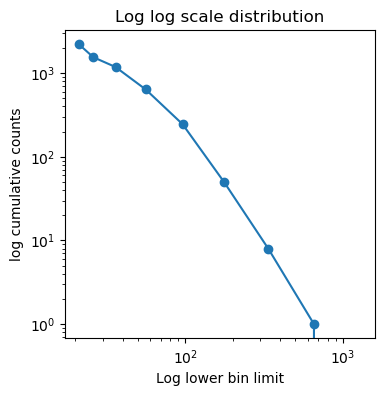

In [12]:
# Do not change

cumsum = cumulative_sum(lower_bin_limits,counts).dropna()

### Choose bins you want to use for linear regression
first_bin_number: First bin you wish to use for linear regression (=1 if you want to use the first bin)

last_bin_number: Last bin you want to use for linear regression (=7 if the seventh bin is the last you wish to use)

cumulative_counts: cumulative_sum function result

lower_bin_limits: should be table formated

In [13]:
# To be changed

first_bin_number = 1
last_bin_number = 8

/opt/conda/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


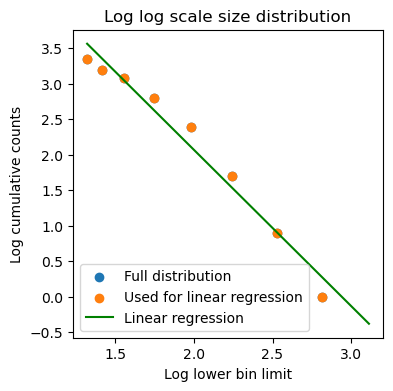

There is  2976628  paricles in the [1, 5000] range.


In [14]:
# Do not change

N, slope, intercept=finding_N(first_bin=first_bin_number,last_bin=last_bin_number,
                            cumulative_counts=cumsum,
                            lower_bin_limits= lower_bin_limits,
                            xmin=interval_of_interest[0], xmax=interval_of_interest[1])

print('There is ',N ,' paricles in the', interval_of_interest,'range.')

### Error on slope and on N 

Slope loop:   0%|          | 0/8 [00:00<?, ?it/s]

slope: -3.4 LOD: 21.0 n: 656


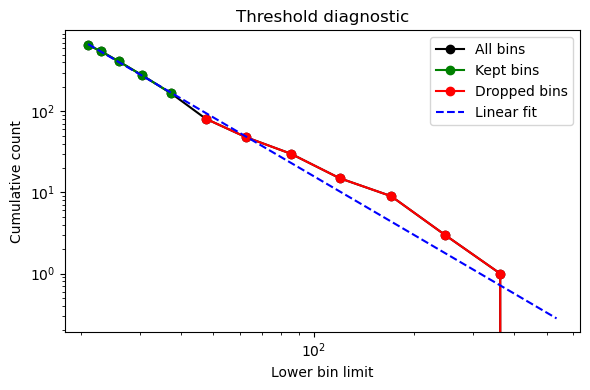

slope: -3.4 LOD: 21.0 n: 756


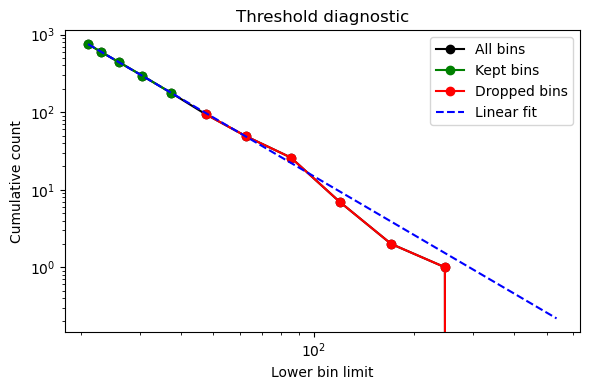

slope: -3.4 LOD: 22.0 n: 656


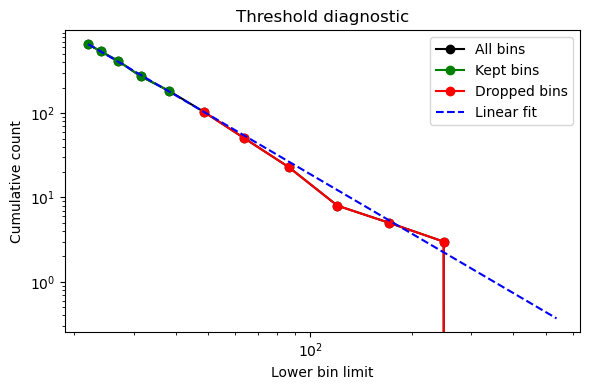

slope: -3.4 LOD: 22.0 n: 756


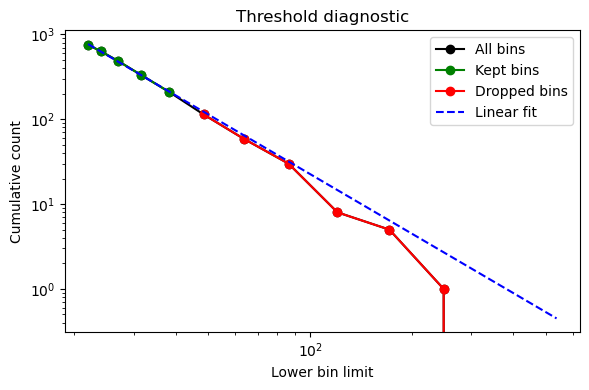

Slope loop:  12%|█▎        | 1/8 [00:03<00:24,  3.52s/it]

slope: -3.071428571428571 LOD: 21.0 n: 656


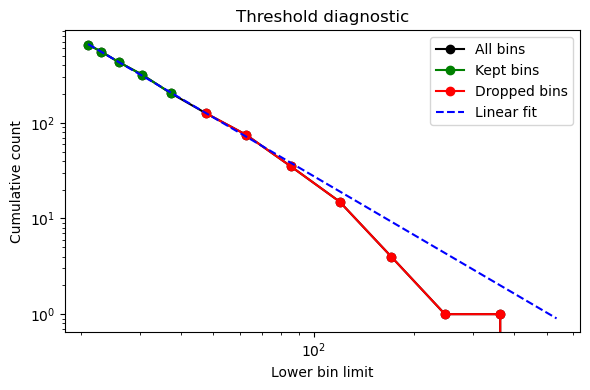

slope: -3.071428571428571 LOD: 21.0 n: 756


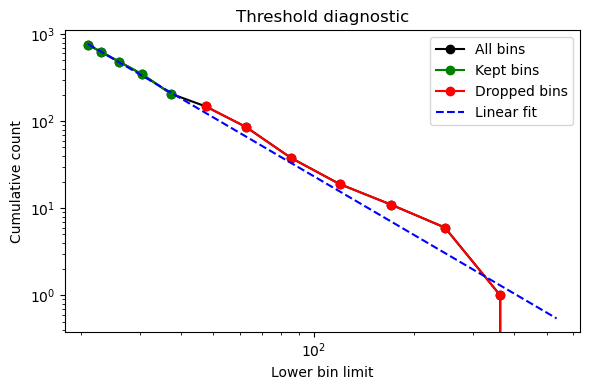

slope: -3.071428571428571 LOD: 22.0 n: 656


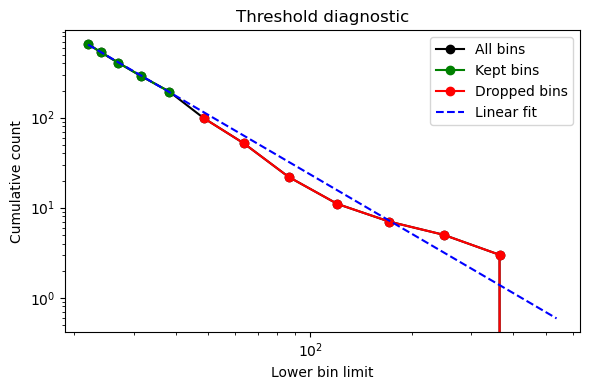

slope: -3.071428571428571 LOD: 22.0 n: 756


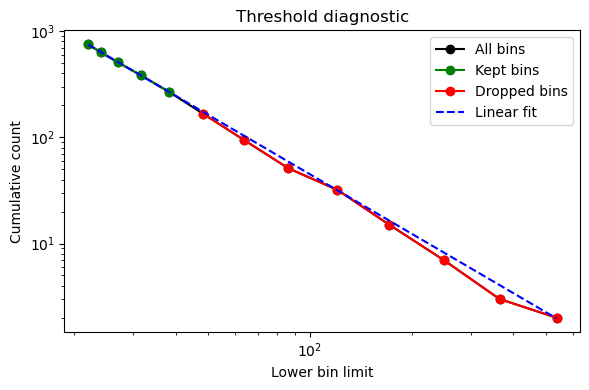

Slope loop:  25%|██▌       | 2/8 [00:06<00:20,  3.49s/it]

slope: -2.742857142857143 LOD: 21.0 n: 656


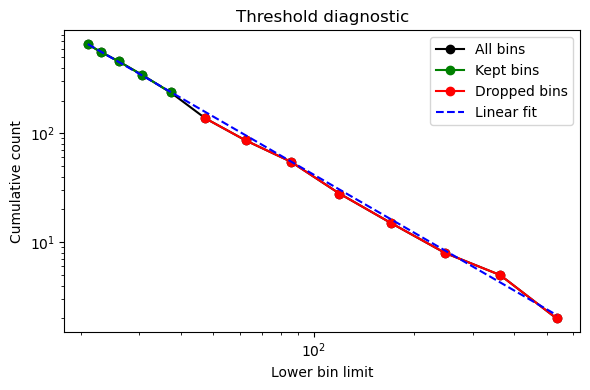

slope: -2.742857142857143 LOD: 21.0 n: 756


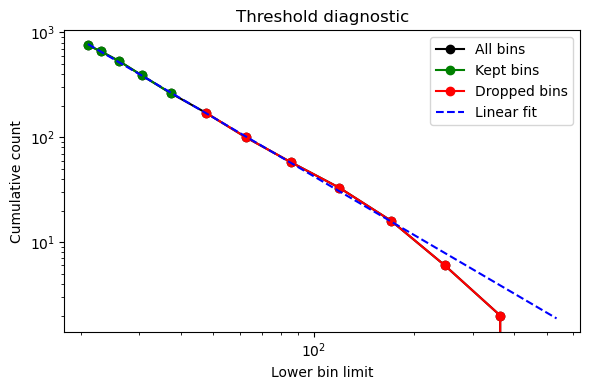

slope: -2.742857142857143 LOD: 22.0 n: 656


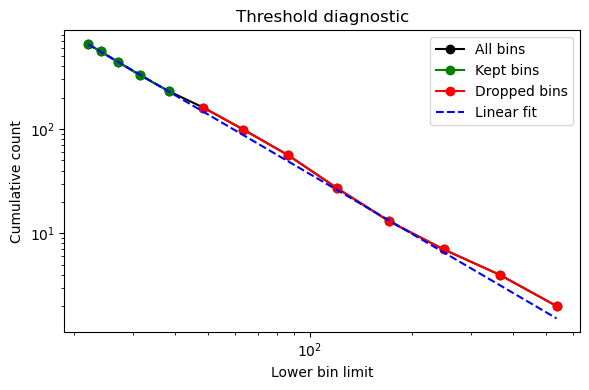

slope: -2.742857142857143 LOD: 22.0 n: 756


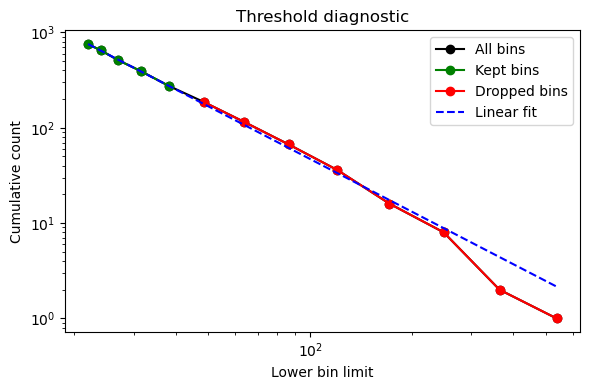

Slope loop:  38%|███▊      | 3/8 [00:10<00:16,  3.38s/it]

slope: -2.414285714285714 LOD: 21.0 n: 656


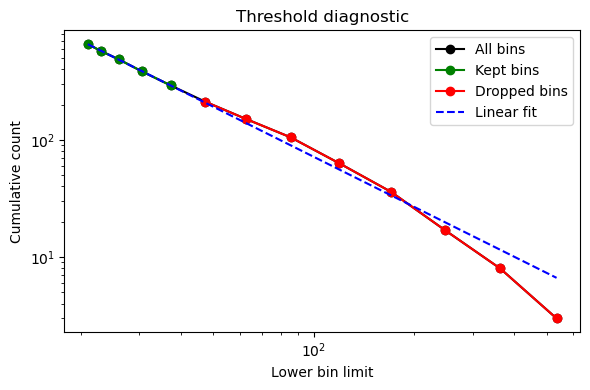

slope: -2.414285714285714 LOD: 21.0 n: 756


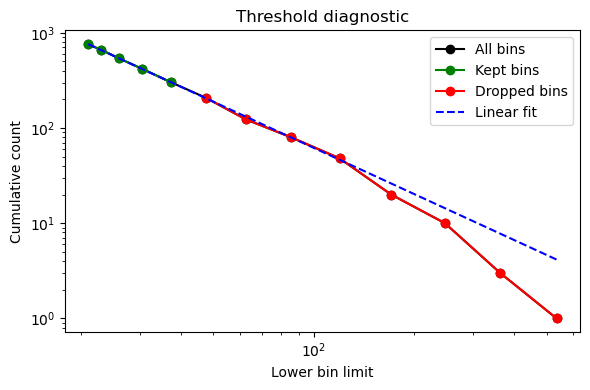

slope: -2.414285714285714 LOD: 22.0 n: 656


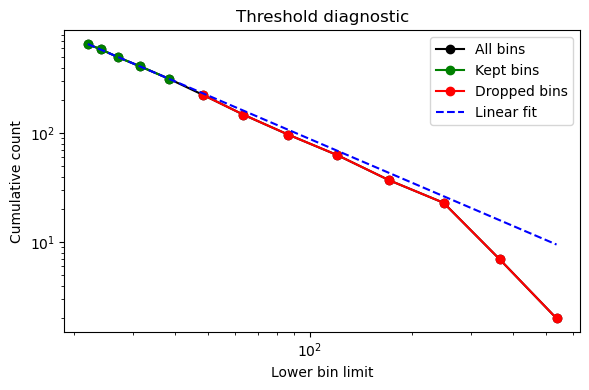

slope: -2.414285714285714 LOD: 22.0 n: 756


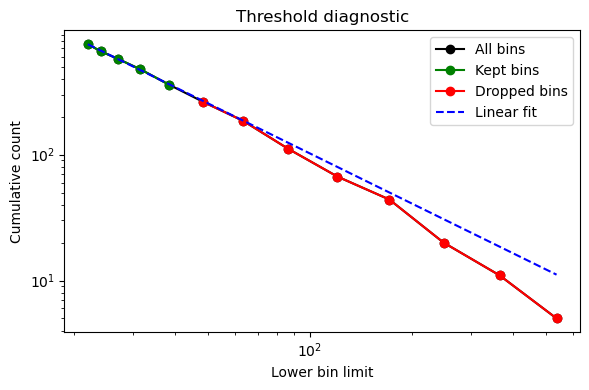

Slope loop:  50%|█████     | 4/8 [00:13<00:13,  3.26s/it]

slope: -2.0857142857142854 LOD: 21.0 n: 656


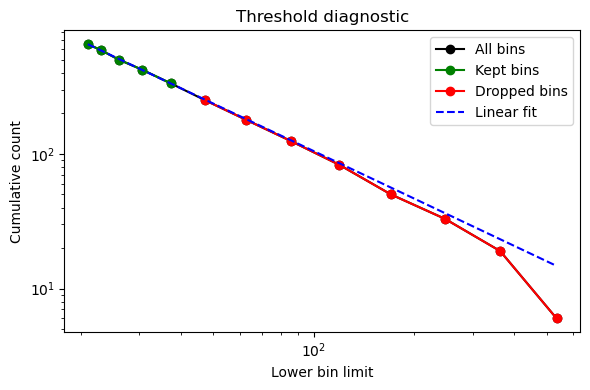

slope: -2.0857142857142854 LOD: 21.0 n: 756


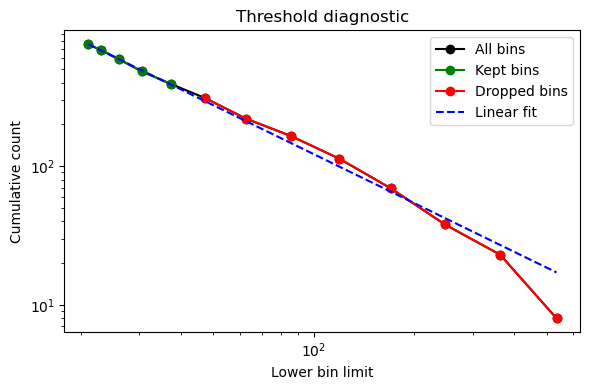

slope: -2.0857142857142854 LOD: 22.0 n: 656


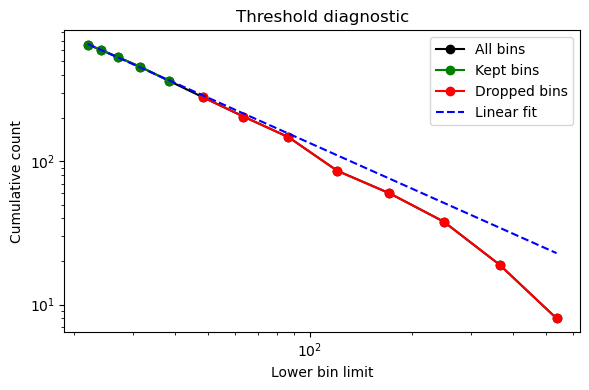

slope: -2.0857142857142854 LOD: 22.0 n: 756


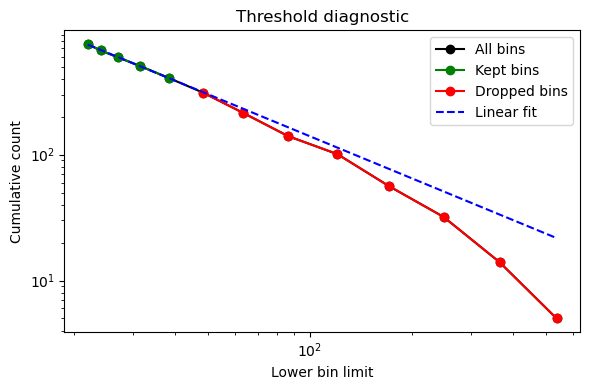

Slope loop:  62%|██████▎   | 5/8 [00:16<00:09,  3.16s/it]

slope: -1.7571428571428571 LOD: 21.0 n: 656


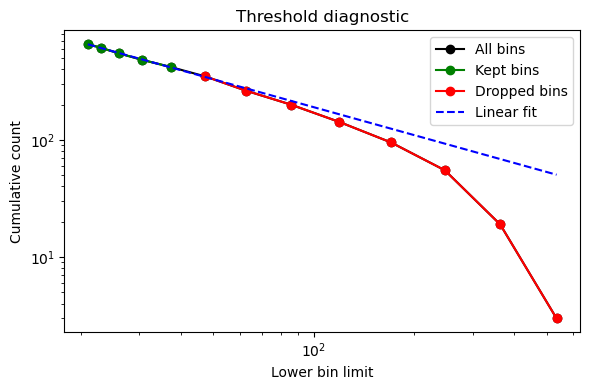

slope: -1.7571428571428571 LOD: 21.0 n: 756


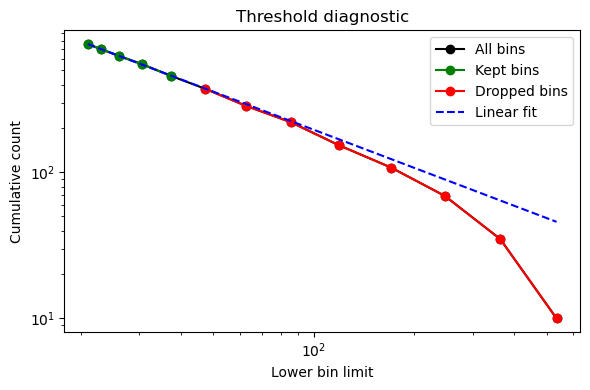

slope: -1.7571428571428571 LOD: 22.0 n: 656


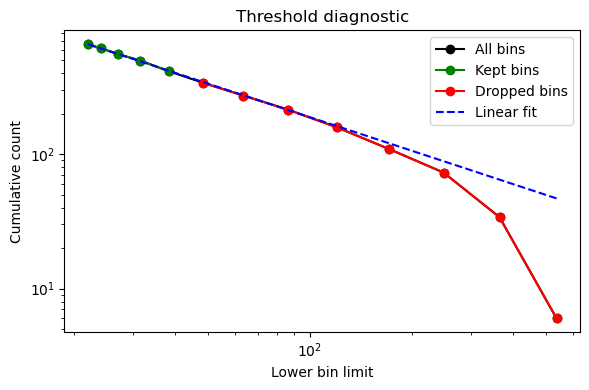

slope: -1.7571428571428571 LOD: 22.0 n: 756


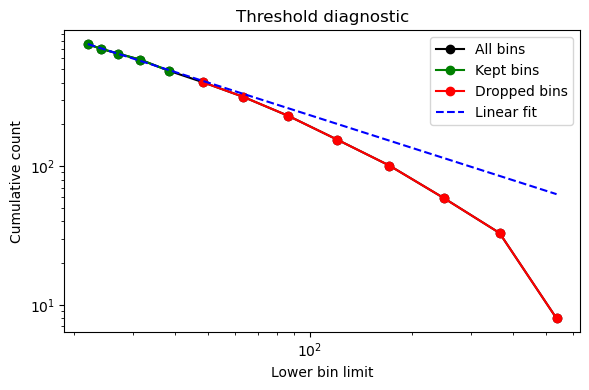

Slope loop:  75%|███████▌  | 6/8 [00:19<00:06,  3.18s/it]

slope: -1.4285714285714284 LOD: 21.0 n: 656


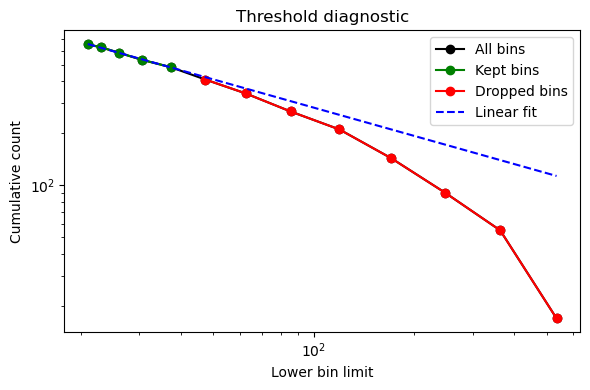

slope: -1.4285714285714284 LOD: 21.0 n: 756


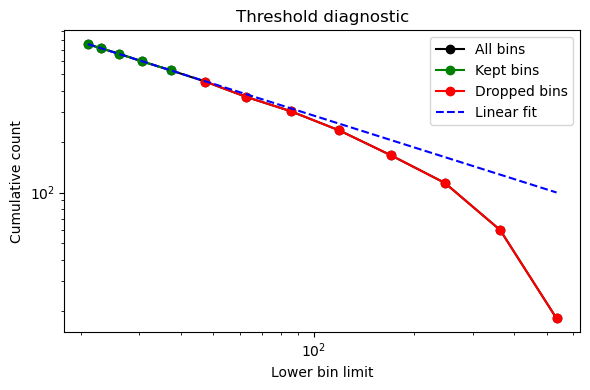

slope: -1.4285714285714284 LOD: 22.0 n: 656


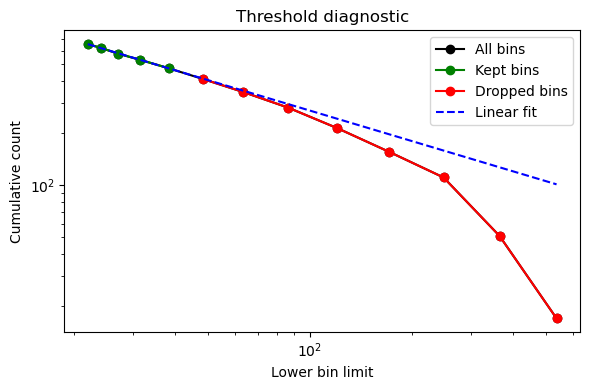

slope: -1.4285714285714284 LOD: 22.0 n: 756


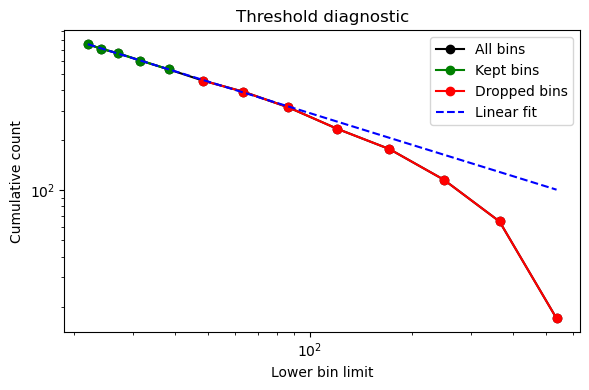

Slope loop:  88%|████████▊ | 7/8 [00:22<00:03,  3.06s/it]

slope: -1.1 LOD: 21.0 n: 656


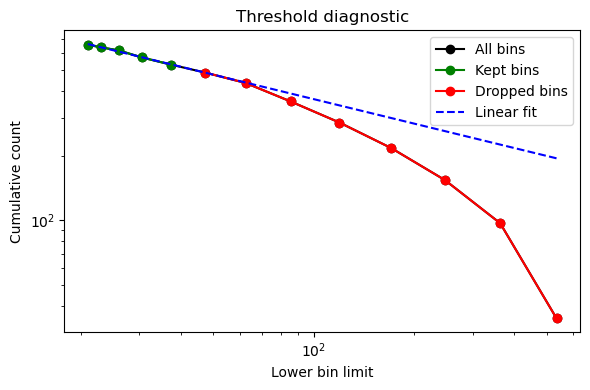

slope: -1.1 LOD: 21.0 n: 756


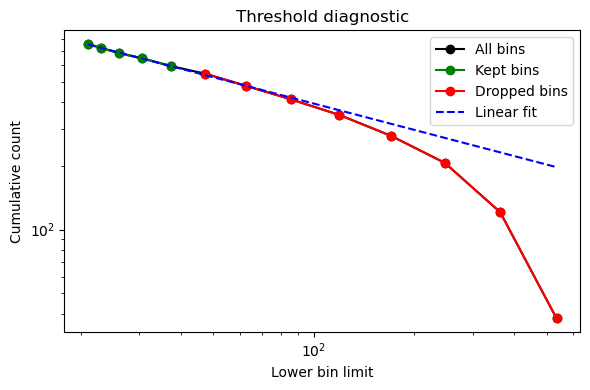

slope: -1.1 LOD: 22.0 n: 656


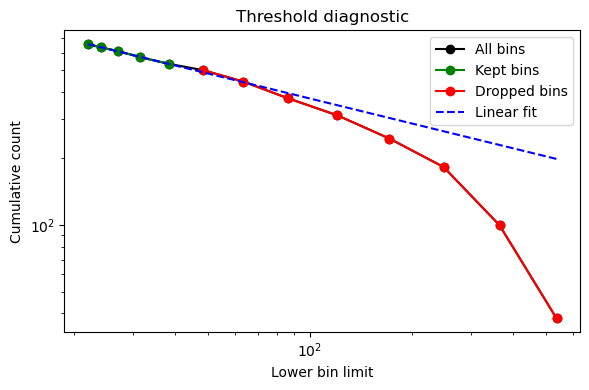

slope: -1.1 LOD: 22.0 n: 756


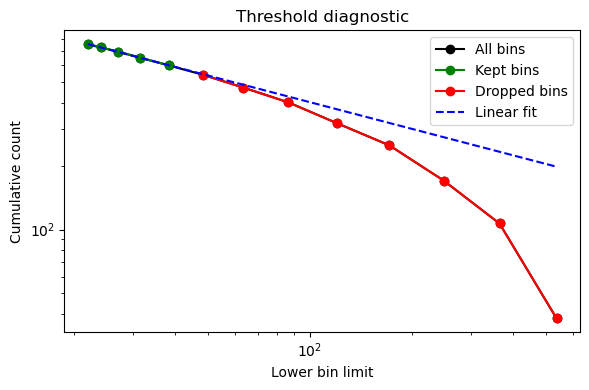

Slope loop: 100%|██████████| 8/8 [00:25<00:00,  3.16s/it]


In [19]:
# Can be changed

# Parameters defining 3D matrix with multiplicative error on N
slopes = np.linspace(-3.4, -1.1, 8)
LOD_low = np.linspace(my_LOD_low, 22, 2)
LOD_high = my_LOD_high
ns = np.linspace(number_of_sampled_particles, number_of_sampled_particles+100, 2 , dtype=int)
xmin, xmax = interval_of_interest

# Verify binning and linear regressions on the plots - you may need to adjust the thresholds in determine_bin_threshold function
# Plot of the first sampling campaign out of 200
results = error_evaluation(slope=slopes, LODs_low=LOD_low, LOD_high=LOD_high, ns=ns, xmin=xmin, xmax=xmin)


### Plot error as a function of slope and your sampling parameters

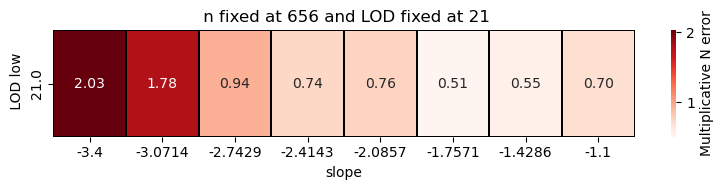

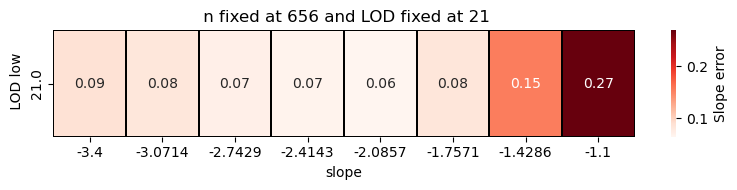

Rappel: My estimated slope is -3.202428979173378


In [20]:
# Do not change

error_plot(n_fixed=number_of_sampled_particles,
           LOD_fixed = my_LOD_low, 
           results_df=results)
print('Rappel: My estimated slope is',slope)

### Estimating total mass

In [15]:
# To be changed 
my_N_error=2.03
my_slope_error = 0.09            # Adjust the error you want to consider
density = 1.00E-06
r = 6
sampling_campaigns = 200

In [16]:
# Do not change - choose fragments or fibers

# no error
all_samplings = np.empty((sampling_campaigns, N))
for i in range(sampling_campaigns):
    random_sequence = np.random.uniform(0, 1, N)
    size_distribution=simulated_sampling(LOD_min_ss=interval_of_interest[0], LOD_max_ss=interval_of_interest[1], b_ss=slope, samples_ss=random_sequence)
    mass_distribution=(np.pi/6)*(size_distribution**3)*(0.7**3)*density                                              # for fragments
    #mass_distribution=(np.pi)*(size_distribution)*(r**2)*density                                                      # for fibers
    all_samplings[i, :]=np.sum(mass_distribution)
Mass = np.mean(all_samplings)
print('Estimated MP mass in the interval of interest is', Mass, 'micrograms.')


Estimated MP mass in the interval of interest is 0.4509470952520228 micrograms.


In [17]:
# Do not change

# + error
all_samplings = np.empty((sampling_campaigns, N))
for i in range(sampling_campaigns):
    random_sequence = np.random.uniform(0, 1, N)
    size_distribution=simulated_sampling(LOD_min_ss=interval_of_interest[0], LOD_max_ss=interval_of_interest[1], b_ss=slope+my_slope_error, samples_ss=random_sequence)
    mass_distribution=(np.pi/6)*(size_distribution**3)*(0.7**3)*density                                              # for fragments
    #mass_distribution=(np.pi)*(size_distribution)*(r**2)*density                                                      # for fibers
    all_samplings[i, :]=np.sum(mass_distribution)
Mass_plus = np.mean(all_samplings)


In [18]:
# Do not change

# - error
all_samplings = np.empty((sampling_campaigns, N))
for i in range(sampling_campaigns):
    random_sequence = np.random.uniform(0, 1, N)
    size_distribution=simulated_sampling(LOD_min_ss=interval_of_interest[0], LOD_max_ss=interval_of_interest[1], b_ss=slope-my_slope_error, samples_ss=random_sequence)
    mass_distribution=(np.pi/6)*(size_distribution**3)*(0.7**3)*density                                              # for fragments
    #mass_distribution=(np.pi)*(size_distribution)*(r**2)*density                                                      # for fibers
    all_samplings[i, :]=np.sum(mass_distribution)
Mass_minus = np.mean(all_samplings)


In [19]:
# Do not change
interval = [(Mass_plus),(Mass_minus)]
print('Estimated MP mass interval is [', np.min(interval),':', np.max(interval),'] micrograms.')

Estimated MP mass interval is [ 0.2757172452249892 : 0.6755621950653679 ] micrograms.


In [16]:
def estimate_mass_error_from_sample_count(xmin, xmax, 
                                          slope_value, slope_err, N_value, N_err_rel,
                                          density, iterations=1000):
    
    """Monte Carlo estimation of mass and its uncertainty from uncertain sample count."""

    total_masses = []

    for _ in range(iterations):
        # Tirer 'a' selon incertitude
        
        b = np.random.normal(loc=slope_value, scale=slope_err)

        # Tirer 'samples' (en entier) selon une loi normale
        
        samples = int(np.random.normal(loc=N_value, scale=N_value * N_err_rel))
        
        if samples <= 0:
            samples = -samples


        # Générer un échantillon
        uniform_randoms = np.random.uniform(0, 1, samples)
        MP_sizes = sample_power_law(xmin, xmax, b_spl=b, distribution_spl=uniform_randoms)

        # Masse totale
        MP_masses = (np.pi/6)*(MP_sizes**3)*(0.7**3)*density
        total_mass = np.sum(MP_masses)
        total_masses.append(total_mass)

    total_masses = np.array(total_masses)
    mean_mass = np.mean(total_masses)
    std_mass = np.std(total_masses)

    return mean_mass, std_mass


In [17]:
estimate_mass_error_from_sample_count(xmin=interval_of_interest[0], xmax=interval_of_interest[1], 
                                          slope_value=slope, slope_err=my_slope_error, N_value=N/10, N_err_rel=my_N_error,
                                          density=density, iterations=10000)

(np.float64(301.52212687317876), np.float64(1345.7238390583834))

In [32]:
int(N)

1791